In [1]:
import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT, DATASETS_ROOT

import fiftyone as fo
import torchvision

In [2]:
ds_root = DATASETS_ROOT / "elephants/training_data"

image_files = list(ds_root.glob("**/*_img.jpg"))
print(f"Dataset at {str(ds_root)} has {len(image_files)} total images")

Dataset at /home/dherrera/data/elephants/training_data has 5450 total images


In [3]:
import datetime


def parse_frame_time(filename: str) -> tuple[str, datetime.datetime]:
    CAMERA_NAMES = [
        "zag-elp-cam-016",
        "zag-elp-cam-017",
        "zag-elp-cam-018",
        "zag-elp-cam-019",
    ]
    FPS = 25.0026

    filename = filename.lower()

    # Name is in the shape:
    # {camera}-{dd.mm.yyyy}-{time_start}-{time_end}_{frame_idx}_img.jpg
    # {camera}-{ddmmyyyy}-{time_start}_{frame_idx}_img.jpg

    # Parse {camera}
    camera_prefixes = [
        camera_name for camera_name in CAMERA_NAMES if filename.startswith(camera_name)
    ]
    assert len(camera_prefixes) == 1
    camera_prefix = camera_prefixes[0]

    # Remove camera prefix
    filename = filename[len(camera_prefix) + 1 :]

    import re

    # Parse {date}
    if filename[2] == ".":
        # Name is in format {dd.mm.yyyy}-{hhmmss}-{hhmmss}_{iiiiiiii}_img.jpg
        match = re.search(
            "(?P<day>\d{2}).(?P<month>\d{2}).(?P<year>\d{4})-(?P<hour0>\d{2})(?P<min0>\d{2})(?P<sec0>\d{2})-(?P<hour1>\d{2})(?P<min1>\d{2})(?P<sec1>\d{2})_(?P<frame>\d{8})_img\.jpg",
            filename,
        )
        if match is None:
            raise RuntimeError(f"Could not parse {filename}")
        fields = {k: int(v) for k, v in match.groupdict().items()}
    else:
        # Name is in format {ddmmyyy}-{hhmmss}_{iiiiiiii}_img.jpg
        raise RuntimeError(f"Could not parse {filename}")

    import datetime

    time_point = datetime.datetime(
        *[fields[k] for k in ["year", "month", "day", "hour0", "min0", "sec0"]]
    )
    frame_idx = fields["frame"]
    frame_video_time = datetime.timedelta(seconds=frame_idx / FPS)
    frame_time_point = time_point + frame_video_time
    return camera_prefix, frame_time_point


name = image_files[0].name
print(name)
print(parse_frame_time(name))

ZAG-ELP-CAM-018-25.01.2025-060848-100848_00276799_img.jpg
('zag-elp-cam-018', datetime.datetime(2025, 1, 25, 9, 13, 18, 808636))


In [4]:
import pandas as pd

data = [(f, *parse_frame_time(f.name)) for f in image_files]
df_data = pd.DataFrame(data=data, columns=["filename", "camera", "time_point"])
df_data["time"] = df_data["time_point"] - df_data["time_point"].dt.normalize()
df_data

,filename,camera,time_point,time
0,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-018,2025-01-25 09:13:18.808636,0 days 09:13:18.808636
1,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-018,2025-01-27 08:32:46.981234,0 days 08:32:46.981234
2,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-018,2025-01-25 07:45:42.915249,0 days 07:45:42.915249
3,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-018,2025-01-27 07:59:46.147241,0 days 07:59:46.147241
4,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-018,2025-01-26 15:24:27.127619,0 days 15:24:27.127619
...,...,...,...,...
5445,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-016,2025-01-26 02:05:37.527913,0 days 02:05:37.527913
5446,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-016,2025-01-26 05:17:40.849488,0 days 05:17:40.849488
5447,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-016,2025-01-25 08:32:34.250974,0 days 08:32:34.250974
5448,/home/dherrera/data/elephants/training_data/za...,zag-elp-cam-016,2025-01-26 05:18:02.887196,0 days 05:18:02.887196


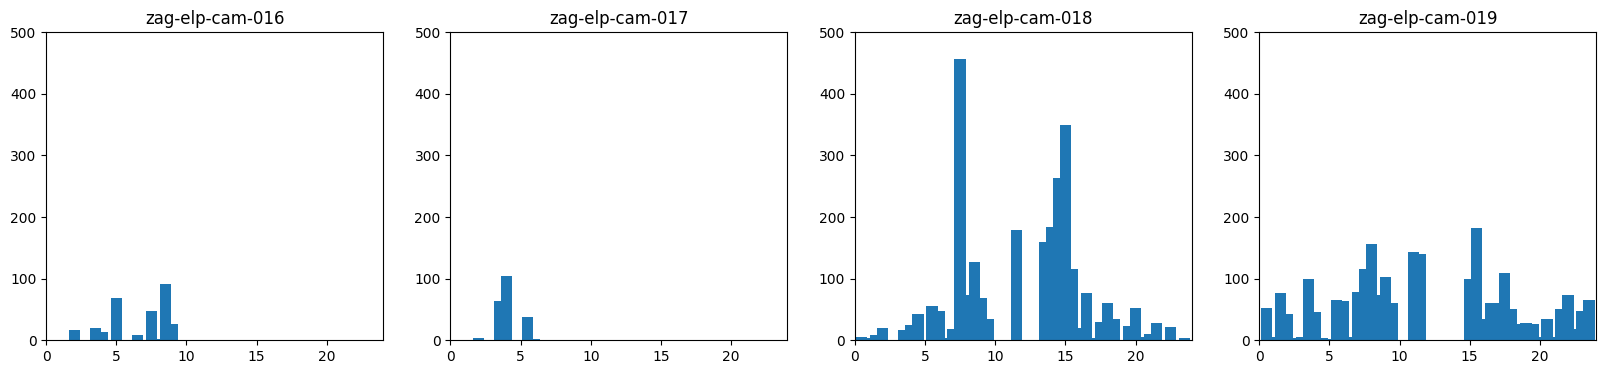

In [5]:
df = df_data.copy()
df["today"] = datetime.date.today()
df["fake_point"] = df["today"].astype("datetime64[s]") + df["time"]
df = df.set_index("fake_point")

counts_per_time = {}
for i, (camera, df_camera) in enumerate(df.groupby("camera")):
    counts = df_camera["time"].resample("30min", origin="start_day").count()
    counts_per_time[camera] = counts.reset_index()


def plot_counts_per_time():
    NCOLS = 4
    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 4))
    axs = axs.reshape(-1)
    for i, (camera, counts) in enumerate(counts_per_time.items()):
        hours = counts["fake_point"].dt.hour + counts["fake_point"].dt.minute / 60

        ax = axs[i]
        ax.bar(hours, counts["time"])
        ax.set_xlim([0, 24])
        ax.set_ylim([0, 500])
        ax.set_title(camera)
    plt.show()


plot_counts_per_time()
# counts

In [6]:
cameras = df_data["camera"].unique()
im_test = {}
for camera in cameras:
    df = df_data[df_data["camera"] == camera]
    file = df["filename"].iloc[0]
    im_test[camera] = cv2.imread(file)
height, width, _ = im_test[cameras[0]].shape
print(f"{width}x{height}")

2688x1520


100%|██████████| 295/295 [00:13<00:00, 21.98it/s]


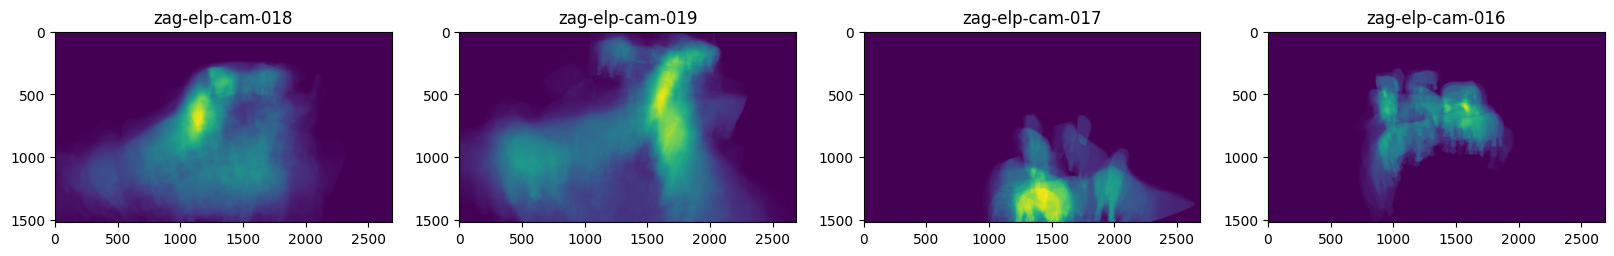

In [7]:
from scripts.datasets.segmentation_utils import bbox_from_mask, label_from_grey
from tqdm import tqdm

coverage = np.zeros((height, width))

cameras = df_data["camera"].unique()
coverages = {}

bbox_data_cols = ["camera", "filename", "label", "x0", "y0", "x1", "y1"]
bbox_data = []

for camera in cameras:
    coverages[camera] = np.zeros((height, width))
    df = df_data[df_data["camera"] == camera]

    for file in tqdm(df["filename"]):
        seg_file = Path(str(file).replace("_img.jpg", "_seg.png"))
        seg = cv2.imread(seg_file, cv2.IMREAD_GRAYSCALE)

        greys = [g for g in np.unique(seg) if g != 0]
        for grey in greys:
            id = label_from_grey(grey)
            mask = seg == grey

            coverages[camera] += mask

            bbox = bbox_from_mask(mask)
            bbox_data.append(
                (
                    camera,
                    file,
                    id,
                    bbox[0],
                    bbox[1],
                    bbox[0] + bbox[2],
                    bbox[1] + bbox[3],
                )
            )
df_bboxes = pd.DataFrame(bbox_data, columns=bbox_data_cols)

NCOLS = 4
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 4))
axs = axs.reshape(-1)
for i, (camera, coverage) in enumerate(coverages.items()):
    ax = axs[i]
    ax.imshow(coverage)
    ax.set_title(camera)

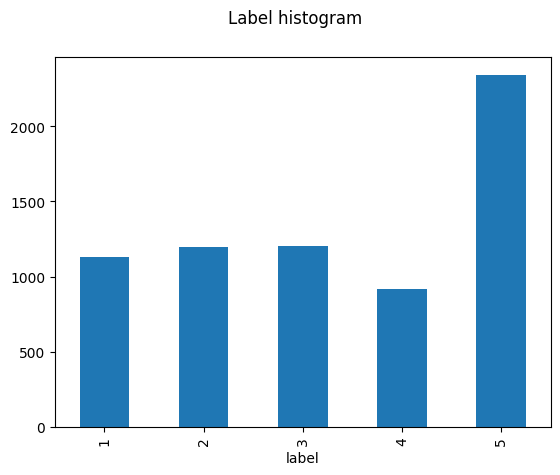

In [8]:
def plot_label_hist():
    df_bboxes.groupby("label")["camera"].count().plot(kind="bar")
    plt.suptitle("Label histogram")
    plt.show()


plot_label_hist()

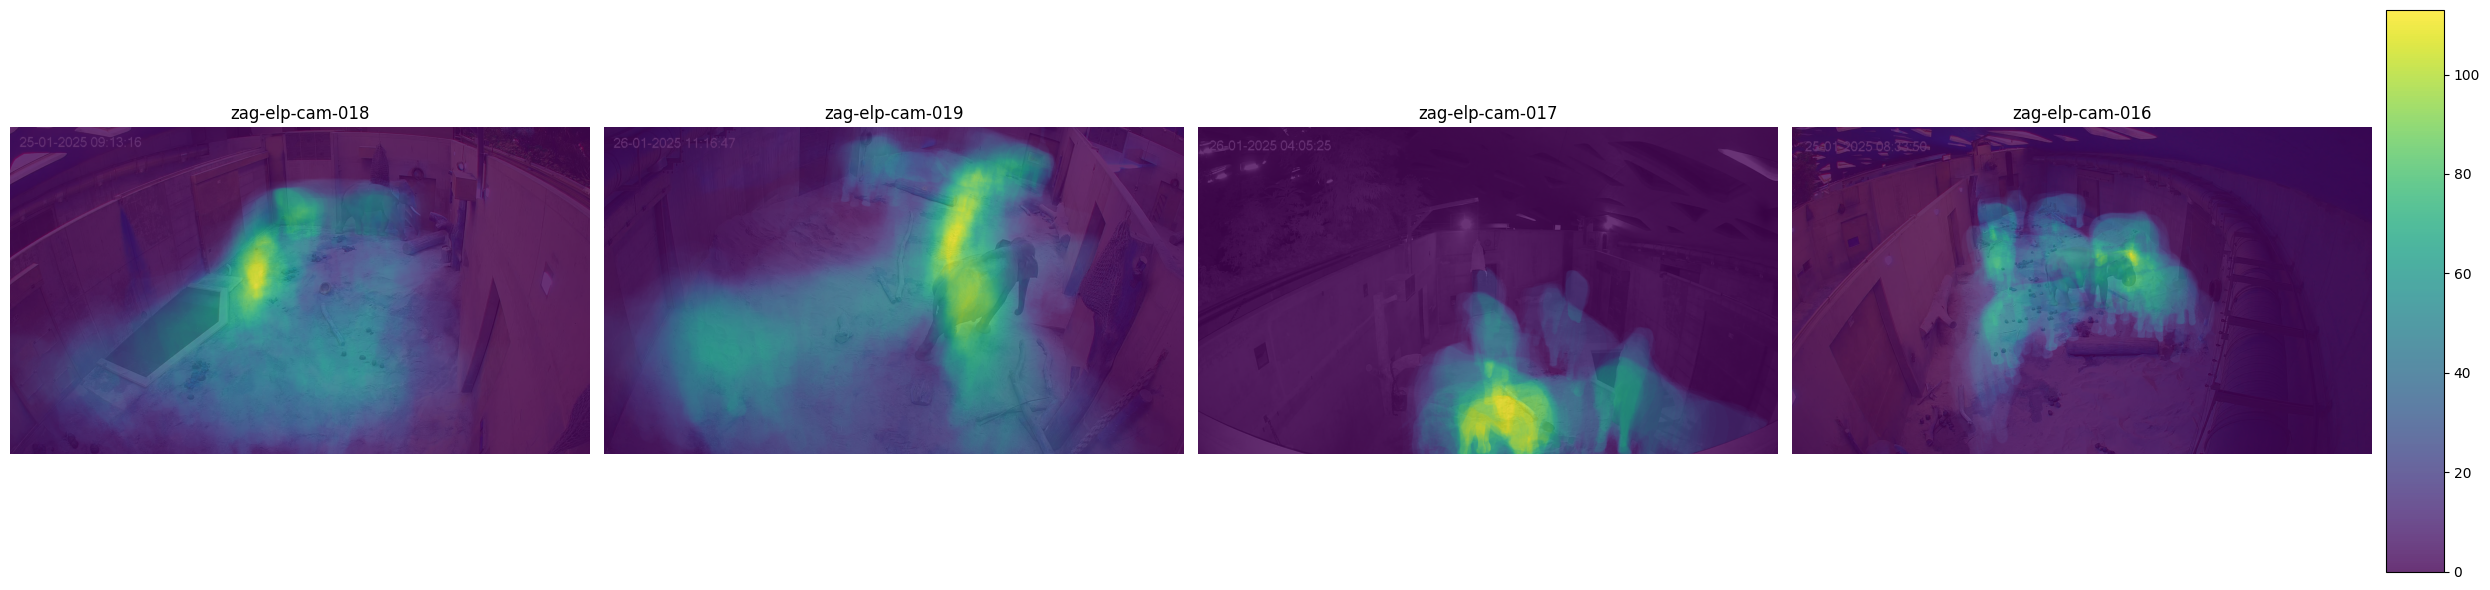

In [9]:
def plot_coverage(limit=100):
    NCOLS = 4
    gs = plt.GridSpec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.1])
    fig = plt.figure(figsize=(25, 6))
    for i, (camera, coverage) in enumerate(coverages.items()):
        ax = fig.add_subplot(gs[i])
        ax.imshow(im_test[camera])
        cb = ax.imshow(np.clip(coverage, 0, limit), alpha=0.8)
        ax.set_title(camera)
        ax.set_axis_off()
    ax = fig.add_subplot(gs[4])
    plt.colorbar(cb, ax)
    fig.tight_layout()
    plt.show()


plot_coverage(limit=1000)

In [10]:
def bboxes_overlap(bboxa, bboxb):
    x_intersect = bboxa[0] >= bboxb[0] and bboxa[0] <= bboxb[2]
    y_intersect = bboxa[1] >= bboxb[1] and bboxa[1] <= bboxb[3]
    return x_intersect and y_intersect


count = 0
overlapping_count = 0
df_bboxes["filename"] = df_bboxes["filename"].astype(str)
for f, group in df_bboxes.groupby("filename"):
    if group.shape[0] <= 1:
        continue
    count += 1
    xa0, xb0 = group["x0"]
    ya0, yb0 = group["y0"]
    xa1, xb1 = group["x1"]
    ya1, yb1 = group["y1"]
    bboxa = (xa0, ya0, xa1, ya1)
    bboxb = (xb0, yb0, xb1, yb1)
    if bboxes_overlap(bboxa, bboxb):
        overlapping_count += 1


def plot_bbox_stats():
    print(f"Total files with more than one bbox: {count}")
    print(f"Total files with overlapping bboxes: {overlapping_count}")


plot_bbox_stats()

Total files with more than one bbox: 1346
Total files with overlapping bboxes: 86


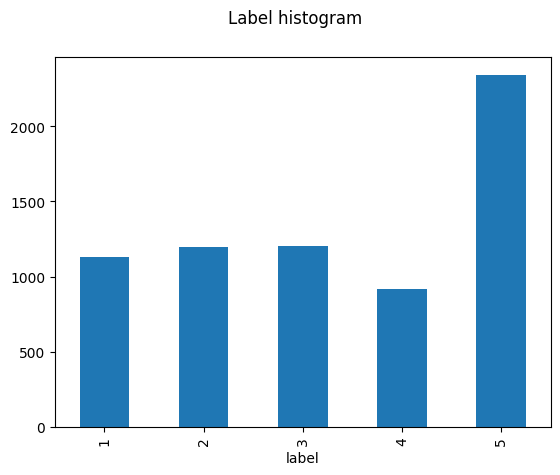

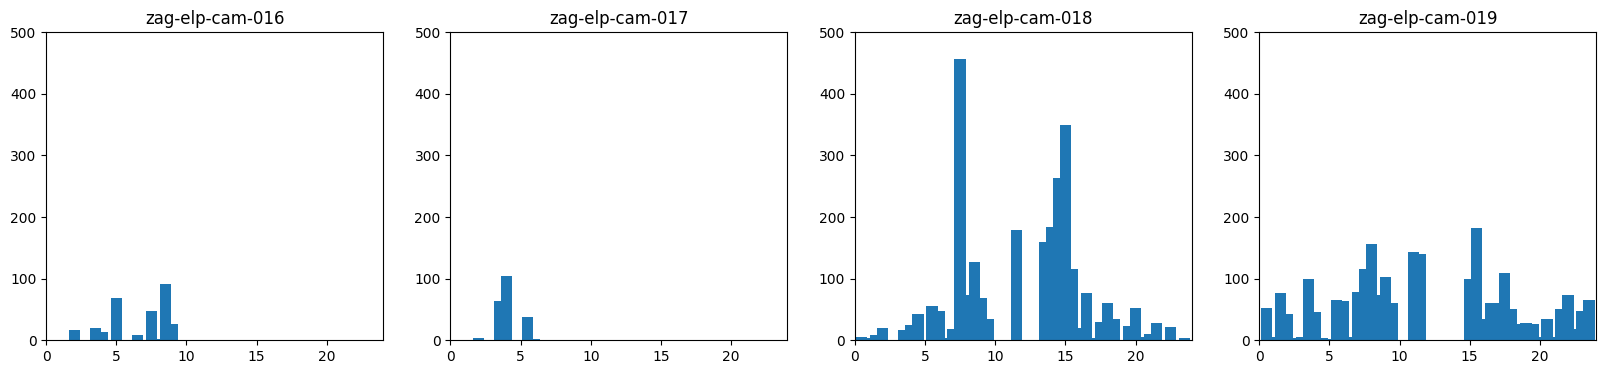

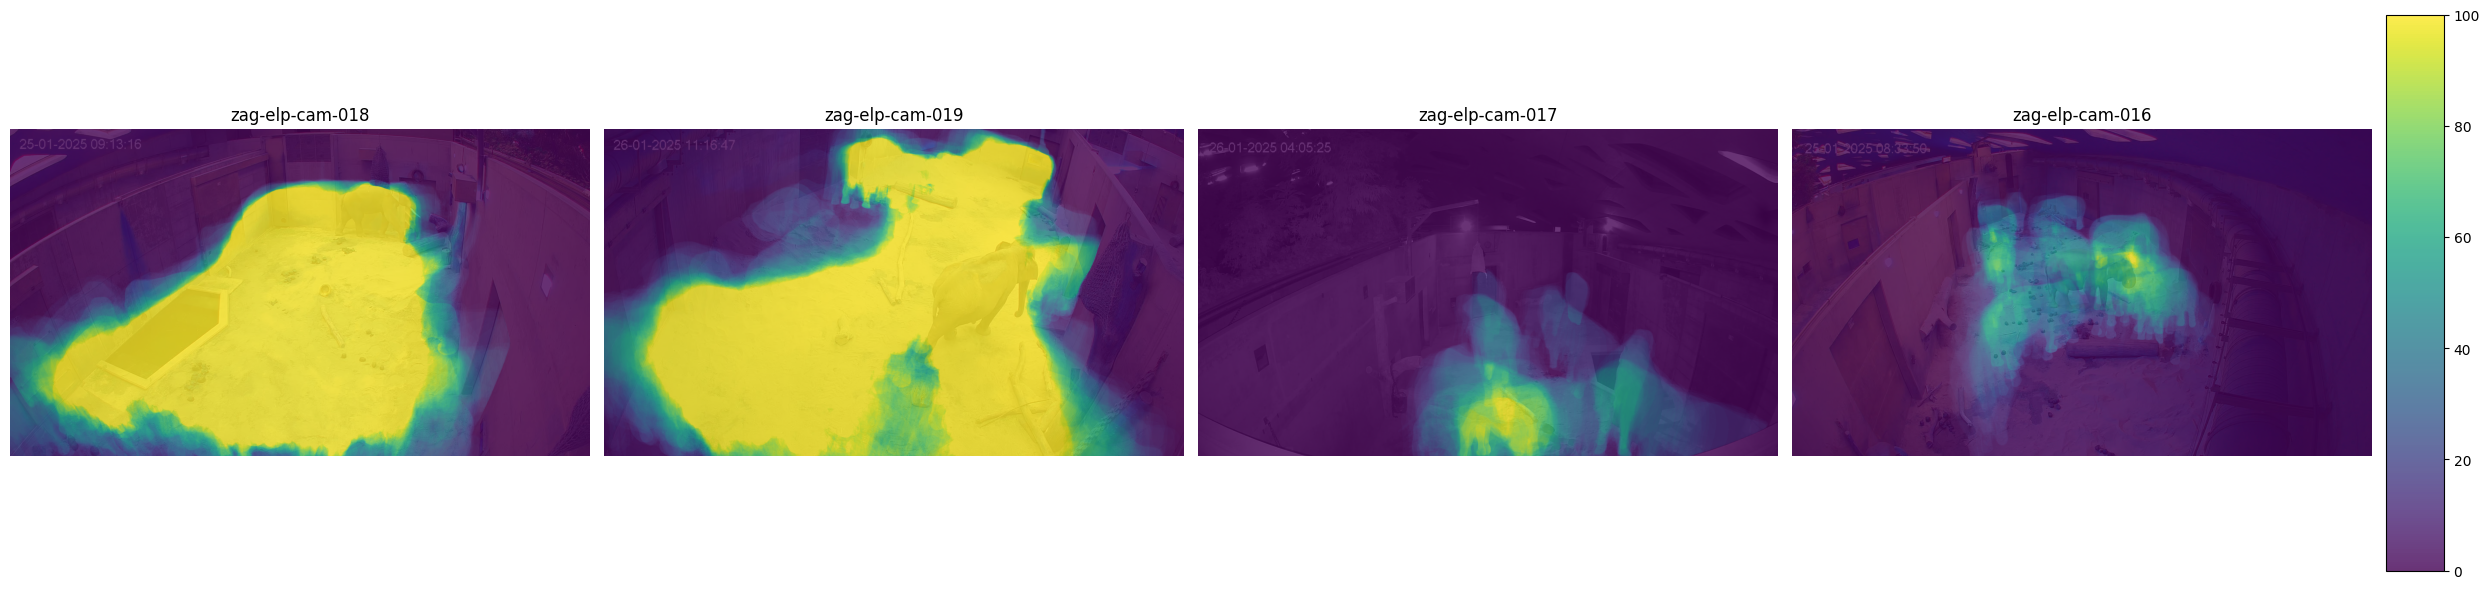

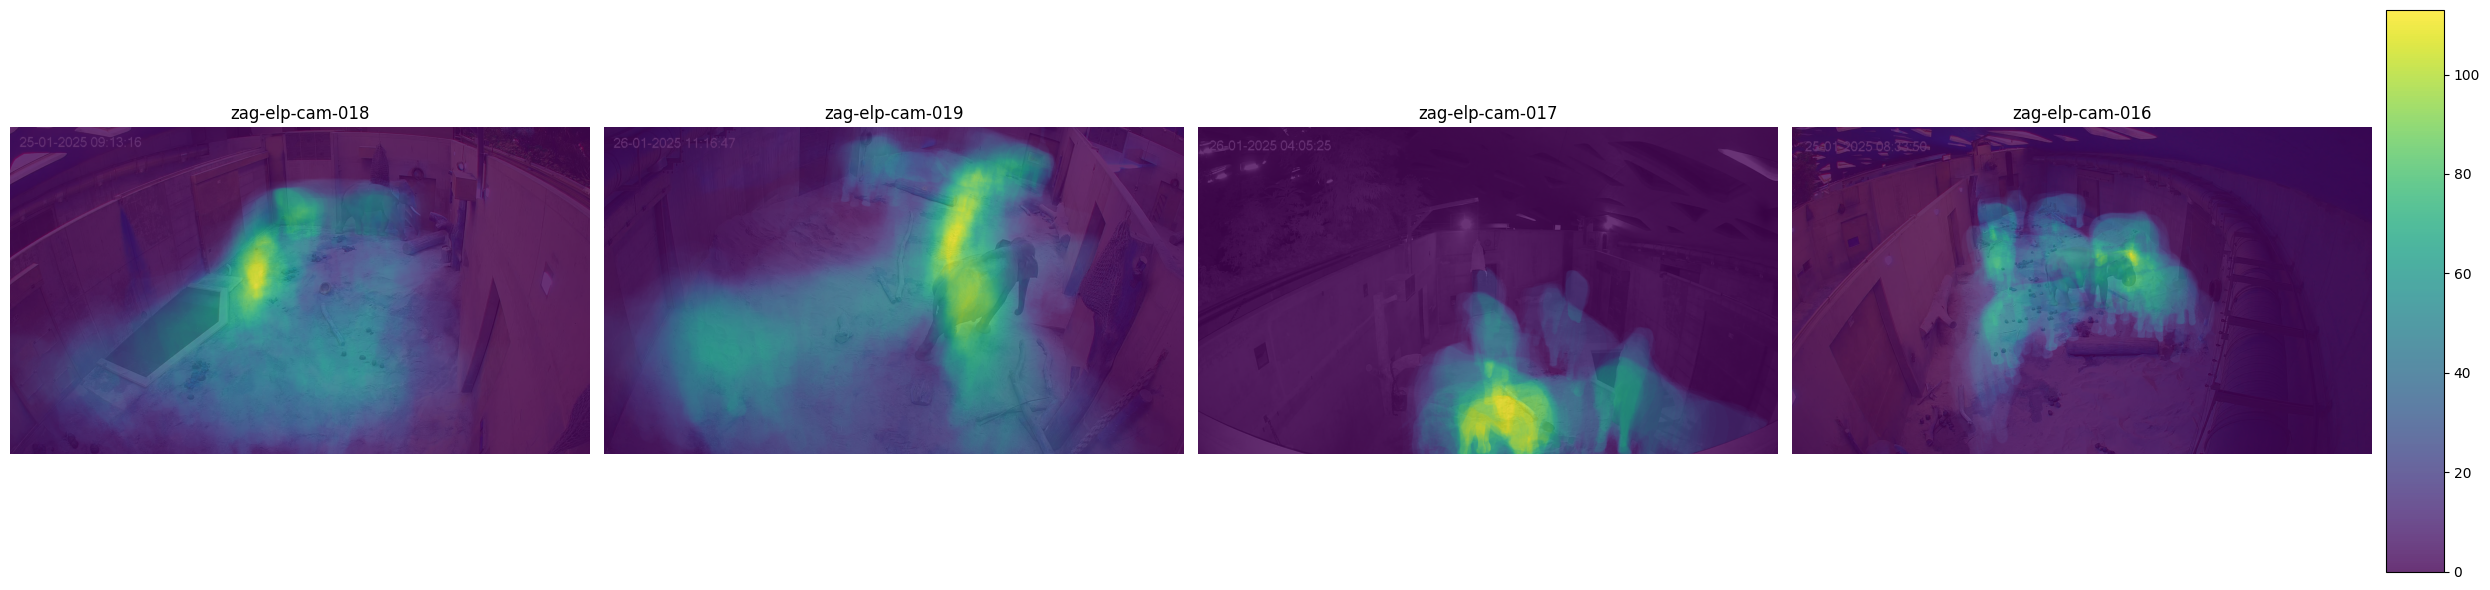

Total files with more than one bbox: 1346
Total files with overlapping bboxes: 86


In [11]:
####################################
# Full report
plot_label_hist()
plot_counts_per_time()
plot_coverage()
plot_coverage(limit=1000)
plot_bbox_stats()